Problems with Fitting Linear Models

This document contains an explanation of a few problems that arise when fitting linear models along with explanations, visuals, and generated data. 

Correlation of Error Terms

A key assumption of linear regression is that the error terms are not correlated. When this assumption is violated, the model's estimated standard errors become too small. Confidence intervals and p-values become too small, which can lead to declaring predictors statistically significant incorrectly. This problem is common in time series data. Observations close together in time can share similar errors. It can also happen when observations share common influences, like family members in a health study. To detect it, you can plot residuals over time and look for "tracking" — a pattern where adjacent residuals take on similar values. Addressing it usually requires using modeling techniques designed for correlated errors or improving experimental design to reduce the source of dependence in the first place.

Question: Is there a statistical test to check for correlated errors?

Answer: Some tests I found while researching this question were the Durbin-Watson Test and the Ljung-Box test. In addition, Generalized Least Squares are much better at accounting for correlated errors when compared to Ordinary Least Squares.

Generated Code

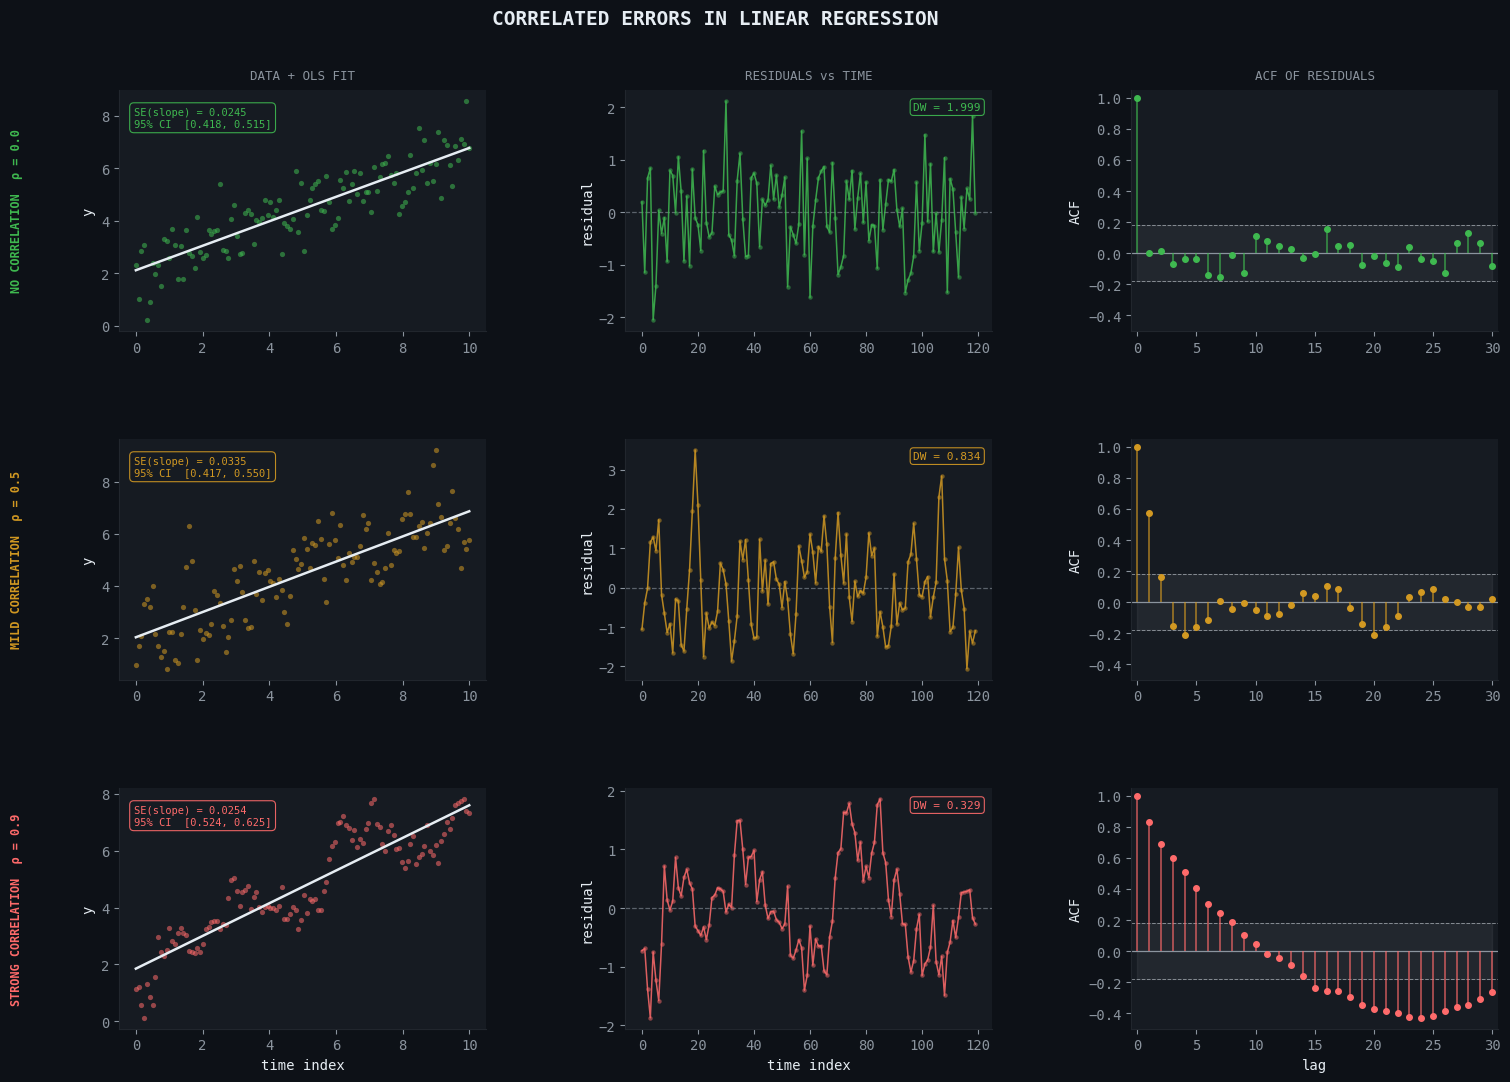

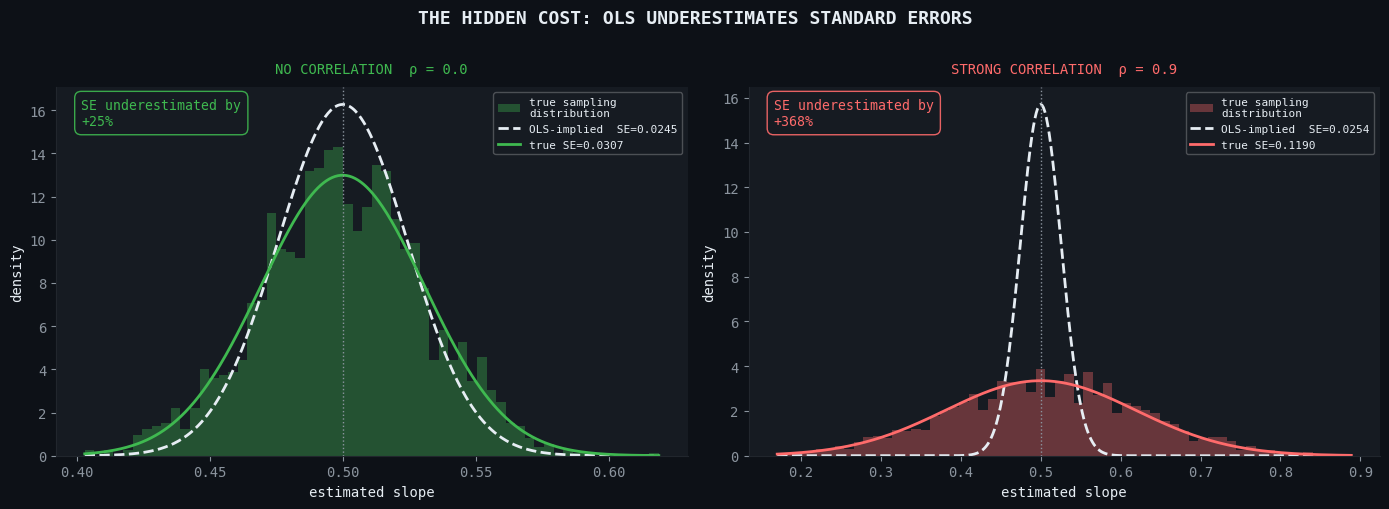

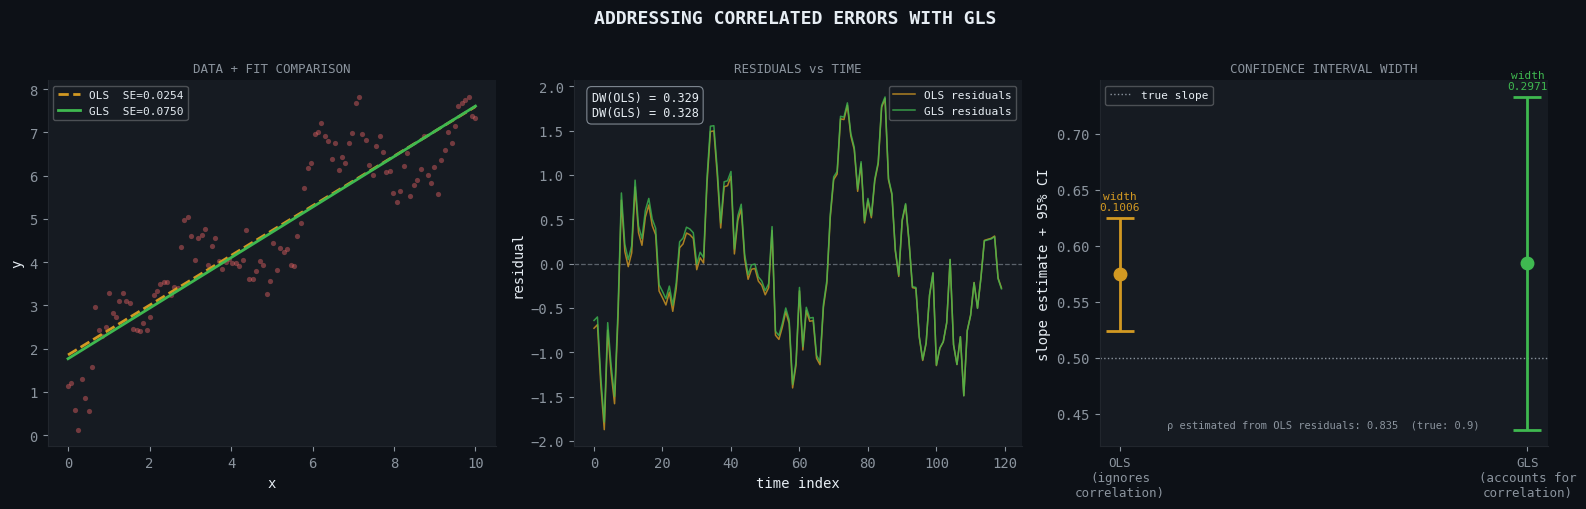

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetics ────────────────────────────────────────────────────────────────
DARK   = "#0d1117"
PANEL  = "#161b22"
GRID   = "#21262d"
TEXT   = "#e6edf3"
MUTED  = "#8b949e"
RED    = "#ff6b6b"
GREEN  = "#3fb950"
BLUE   = "#58a6ff"
YELLOW = "#d29922"
PURPLE = "#bc8cff"

plt.rcParams.update({
    "figure.facecolor":  DARK,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "text.color":        TEXT,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(42)
n   = 120
t   = np.arange(n)

# ── Synthetic data ─────────────────────────────────────────────────────────────
# True relationship: y = 2 + 0.5*x + ε
x = np.linspace(0, 10, n)
true_slope, true_intercept = 0.5, 2.0

def ar1_errors(n, rho, sigma=1.0, rng=rng):
    """Generate AR(1) correlated errors."""
    eps = np.zeros(n)
    eps[0] = rng.normal(0, sigma)
    for i in range(1, n):
        eps[i] = rho * eps[i-1] + rng.normal(0, sigma * np.sqrt(1 - rho**2))
    return eps

eps_uncorr  = rng.normal(0, 1, n)
eps_mild    = ar1_errors(n, rho=0.5)
eps_strong  = ar1_errors(n, rho=0.9)

y_uncorr = true_intercept + true_slope * x + eps_uncorr
y_mild   = true_intercept + true_slope * x + eps_mild
y_strong = true_intercept + true_slope * x + eps_strong


def fit_ols(x, y):
    X = add_constant(x)
    model = OLS(y, X).fit()
    return model


model_u = fit_ols(x, y_uncorr)
model_m = fit_ols(x, y_mild)
model_s = fit_ols(x, y_strong)

resid_u = model_u.resid
resid_m = model_m.resid
resid_s = model_s.resid


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – The Problem in Three Panels
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(3, 3, figsize=(16, 11))
fig1.suptitle("CORRELATED ERRORS IN LINEAR REGRESSION", fontsize=14,
              fontweight="bold", color=TEXT, y=0.98)

configs = [
    (resid_u, y_uncorr, "NO CORRELATION  ρ = 0.0", GREEN,
     model_u, eps_uncorr),
    (resid_m, y_mild,   "MILD CORRELATION  ρ = 0.5", YELLOW,
     model_m, eps_mild),
    (resid_s, y_strong, "STRONG CORRELATION  ρ = 0.9", RED,
     model_s, eps_strong),
]

for row, (resid, y, label, color, model, eps) in enumerate(configs):
    dw  = durbin_watson(resid)
    se  = model.bse[1]          # SE of slope
    ci  = model.conf_int()[1]

    # ── col 0: scatter + fit ─────────────────────────────────────────
    ax = axes[row, 0]
    ax.scatter(x, y, s=14, alpha=0.55, color=color, linewidths=0)
    ax.plot(x, model.fittedvalues, color=TEXT, lw=1.8, zorder=5)
    ax.set_ylabel("y", labelpad=4)
    if row == 0:
        ax.set_title("DATA + OLS FIT", fontsize=9, color=MUTED, pad=8)
    ax.text(0.04, 0.93,
            f"SE(slope) = {se:.4f}\n95% CI  [{ci[0]:.3f}, {ci[1]:.3f}]",
            transform=ax.transAxes, fontsize=7.5, color=color,
            va="top", family="monospace",
            bbox=dict(facecolor=PANEL, edgecolor=color, lw=0.8,
                      boxstyle="round,pad=0.4", alpha=0.9))
    ax.text(-0.28, 0.5, label, transform=ax.transAxes,
            fontsize=8.5, fontweight="bold", color=color,
            rotation=90, va="center", ha="center")

    # ── col 1: residuals vs time ──────────────────────────────────────
    ax = axes[row, 1]
    ax.axhline(0, color=MUTED, lw=0.9, ls="--", alpha=0.6)
    ax.plot(t, resid, color=color, lw=1.1, alpha=0.85)
    ax.scatter(t, resid, s=10, color=color, alpha=0.5, linewidths=0)
    ax.set_ylabel("residual", labelpad=4)
    if row == 0:
        ax.set_title("RESIDUALS vs TIME", fontsize=9, color=MUTED, pad=8)
    ax.text(0.97, 0.95, f"DW = {dw:.3f}",
            transform=ax.transAxes, fontsize=8, color=color,
            ha="right", va="top",
            bbox=dict(facecolor=PANEL, edgecolor=color, lw=0.8,
                      boxstyle="round,pad=0.3", alpha=0.9))

    # ── col 2: ACF of residuals ───────────────────────────────────────
    ax = axes[row, 2]
    nlags = 30
    acf_vals = acf(resid, nlags=nlags, fft=True)
    ci_band  = 1.96 / np.sqrt(n)
    lags_arr = np.arange(nlags + 1)
    ax.axhline(0,         color=MUTED,  lw=0.9)
    ax.axhline( ci_band,  color=TEXT,   lw=0.7, ls="--", alpha=0.5)
    ax.axhline(-ci_band,  color=TEXT,   lw=0.7, ls="--", alpha=0.5)
    ax.fill_between(lags_arr, -ci_band, ci_band, color=TEXT, alpha=0.06)
    markerline, stemlines, baseline = ax.stem(
        lags_arr, acf_vals, linefmt=color, markerfmt="o", basefmt=" ")
    plt.setp(stemlines,   linewidth=1.2, alpha=0.7)
    plt.setp(markerline,  markersize=4,  color=color)
    ax.set_xlim(-0.5, nlags + 0.5)
    ax.set_ylim(-0.5, 1.05)
    ax.set_ylabel("ACF", labelpad=4)
    if row == 0:
        ax.set_title("ACF OF RESIDUALS", fontsize=9, color=MUTED, pad=8)
    if row == 2:
        for col in range(3):
            axes[row, col].set_xlabel("time index" if col < 2 else "lag",
                                      labelpad=4)

fig1.tight_layout(rect=[0.05, 0, 1, 0.97])
fig1.subplots_adjust(hspace=0.45, wspace=0.38)



# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Consequence: Standard Errors Are Underestimated
# ══════════════════════════════════════════════════════════════════════════════
# Bootstrap the TRUE sampling distribution of the slope for the strong-corr case
# and compare against what OLS reports.

B = 2000
boot_slopes_uncorr = np.empty(B)
boot_slopes_strong = np.empty(B)
rng2 = np.random.default_rng(7)

for b in range(B):
    # uncorrelated world
    e_u = rng2.normal(0, 1, n)
    y_b = true_intercept + true_slope * x + e_u
    boot_slopes_uncorr[b] = fit_ols(x, y_b).params[1]

    # strongly correlated world
    e_s = ar1_errors(n, rho=0.9, rng=rng2)
    y_b = true_intercept + true_slope * x + e_s
    boot_slopes_strong[b] = fit_ols(x, y_b).params[1]

# OLS-reported SE (from a single typical fit)
se_ols_uncorr = model_u.bse[1]
se_ols_strong = model_s.bse[1]
# True SE = std of bootstrap distribution
se_true_uncorr = boot_slopes_uncorr.std()
se_true_strong = boot_slopes_strong.std()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("THE HIDDEN COST: OLS UNDERESTIMATES STANDARD ERRORS",
              fontsize=13, fontweight="bold", color=TEXT, y=1.01)

for ax, slopes, se_ols, se_true, label, color in [
    (axes2[0], boot_slopes_uncorr, se_ols_uncorr, se_true_uncorr,
     "NO CORRELATION  ρ = 0.0", GREEN),
    (axes2[1], boot_slopes_strong, se_ols_strong, se_true_strong,
     "STRONG CORRELATION  ρ = 0.9", RED),
]:
    ax.hist(slopes, bins=60, color=color, alpha=0.35, edgecolor="none",
            density=True, label="true sampling\ndistribution")

    # OLS-implied normal curve
    grid = np.linspace(slopes.min(), slopes.max(), 400)
    from scipy.stats import norm
    ax.plot(grid, norm.pdf(grid, true_slope, se_ols),
            color=TEXT, lw=2, ls="--", label=f"OLS-implied  SE={se_ols:.4f}")
    ax.plot(grid, norm.pdf(grid, true_slope, se_true),
            color=color, lw=2, label=f"true SE={se_true:.4f}")

    ax.axvline(true_slope, color=MUTED, lw=1, ls=":")
    ratio = se_true / se_ols
    ax.set_title(label, fontsize=10, color=color, pad=10)
    ax.set_xlabel("estimated slope", labelpad=4)
    ax.set_ylabel("density", labelpad=4)
    ax.legend(fontsize=8, framealpha=0.3, loc="upper right")
    ax.text(0.04, 0.97,
            f"SE underestimated by\n{(ratio-1)*100:+.0f}%",
            transform=ax.transAxes, fontsize=9.5, color=color,
            va="top",
            bbox=dict(facecolor=PANEL, edgecolor=color, lw=1,
                      boxstyle="round,pad=0.5", alpha=0.9))

fig2.tight_layout()



# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – Addressing the Problem via GLS / FGLS
# ══════════════════════════════════════════════════════════════════════════════
from statsmodels.regression.linear_model import GLS
from numpy.linalg import inv

# --- Build the AR(1) covariance matrix for rho=0.9 --------------------------
rho_true = 0.9

def ar1_cov_matrix(n, rho, sigma2=1.0):
    idx = np.arange(n)
    dist = np.abs(idx[:, None] - idx[None, :])
    return sigma2 / (1 - rho**2) * rho**dist

Sigma = ar1_cov_matrix(n, rho_true)

# OLS on strongly-correlated data (already done as model_s)
# FGLS: estimate rho from OLS residuals, then re-fit
rho_est = np.corrcoef(resid_s[:-1], resid_s[1:])[0, 1]
Sigma_est = ar1_cov_matrix(n, rho_est)

X_mat = add_constant(x)
gls_model = GLS(y_strong, X_mat, sigma=Sigma_est).fit()

# Compare confidence intervals for the slope
ols_ci  = model_s.conf_int()[1]
gls_ci  = gls_model.conf_int()[1]
ols_se  = model_s.bse[1]
gls_se  = gls_model.bse[1]

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle("ADDRESSING CORRELATED ERRORS WITH GLS",
              fontsize=13, fontweight="bold", color=TEXT, y=1.01)

# ── Panel A: data + both fits ────────────────────────────────────────────────
ax = axes3[0]
ax.scatter(x, y_strong, s=14, alpha=0.4, color=RED, linewidths=0, zorder=2)
ax.plot(x, model_s.fittedvalues,   color=YELLOW, lw=2,   ls="--",
        label=f"OLS  SE={ols_se:.4f}", zorder=4)
ax.plot(x, gls_model.fittedvalues, color=GREEN,  lw=2,
        label=f"GLS  SE={gls_se:.4f}", zorder=5)
ax.set_title("DATA + FIT COMPARISON", fontsize=9, color=MUTED)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8, framealpha=0.3)

# ── Panel B: residuals ───────────────────────────────────────────────────────
ax = axes3[1]
ax.axhline(0, color=MUTED, lw=0.9, ls="--", alpha=0.6)
ax.plot(t, resid_s,          color=YELLOW, lw=1.1, alpha=0.8, label="OLS residuals")
ax.plot(t, gls_model.resid,  color=GREEN,  lw=1.1, alpha=0.8, label="GLS residuals")
ax.set_title("RESIDUALS vs TIME", fontsize=9, color=MUTED)
ax.set_xlabel("time index"); ax.set_ylabel("residual")
dw_ols = durbin_watson(resid_s)
dw_gls = durbin_watson(gls_model.resid)
ax.text(0.04, 0.97,
        f"DW(OLS) = {dw_ols:.3f}\nDW(GLS) = {dw_gls:.3f}",
        transform=ax.transAxes, fontsize=8.5, va="top",
        bbox=dict(facecolor=PANEL, edgecolor=MUTED, lw=0.8,
                  boxstyle="round,pad=0.4", alpha=0.9))
ax.legend(fontsize=8, framealpha=0.3)

# ── Panel C: CI comparison ────────────────────────────────────────────────────
ax = axes3[2]
methods   = ["OLS\n(ignores\ncorrelation)", "GLS\n(accounts for\ncorrelation)"]
estimates = [model_s.params[1],    gls_model.params[1]]
lowers    = [ols_ci[0],            gls_ci[0]]
uppers    = [ols_ci[1],            gls_ci[1]]
colors    = [YELLOW, GREEN]

for i, (m, est, lo, hi, c) in enumerate(
        zip(methods, estimates, lowers, uppers, colors)):
    ax.errorbar(i, est,
                yerr=[[est - lo], [hi - est]],
                fmt="o", color=c, capsize=10, capthick=2,
                elinewidth=2, markersize=9, zorder=5)
    ax.text(i, hi + 0.005,
            f"width\n{hi-lo:.4f}",
            ha="center", va="bottom", fontsize=8, color=c)

ax.axhline(true_slope, color=MUTED, lw=1, ls=":", label="true slope")
ax.set_xticks([0, 1]); ax.set_xticklabels(methods, fontsize=9)
ax.set_ylabel("slope estimate + 95% CI")
ax.set_title("CONFIDENCE INTERVAL WIDTH", fontsize=9, color=MUTED)
ax.legend(fontsize=8, framealpha=0.3)
ax.text(0.5, 0.05,
        f"ρ estimated from OLS residuals: {rho_est:.3f}  (true: {rho_true})",
        transform=ax.transAxes, ha="center", fontsize=7.5, color=MUTED)

fig3.tight_layout()


Top Figure: Scatter plot, residual plot vs time, and ACF plot showing the difference between data with 0 correlation, moderate correlation and strong correlation of errors. 
Middle Figure: Comparison of the true sampling distribution vs the sampling distrubition produced by Ordinary Least Squares under a 0 error correlation and strong correlation error scenario. The distribution of the strong correlation scenario is unusually narrow, implying very low error. 
Bottom Figure: COmparison of Ordinary Least Squares vs Generalized Least Squares. GLS shows much more of the true error than the OLS when erros are strongly correlated. 

Outliers

While outliers don't always distort the regression line itself, they can still damage model quality by inflating the Residual Squared Error and deflating R^2. This widens confidence intervals and makes p-values larger. The model seems less reliable than it would be without the outlier. Usually, a studentized residual is used to find outlier. Each raw residual is divided by its estimated standard error, and any observation with an absolute studentized residual above 3 should be looked into. If the outlier is from a data collection error, it can be removed. If there is no data collection error, the outlier should not be removed. There could be a missing predictor or a bigger issue with the model.

Question: How does a missing predictor produce an outlier?

Answer:  When a relevant predictor is omitted, its effect gets absorbed into the error term. For most observations this just adds extra randomness. However, where the missing variable takes an extreme value, the residual can be very large. This makes the point look like an outlier when it's actually a regular data point that the incomplete model can't explain. It is helpful to look for patterns among outliers. if they share a common characteristic, it's a strong sign of a missing predictor and not a recording error. 

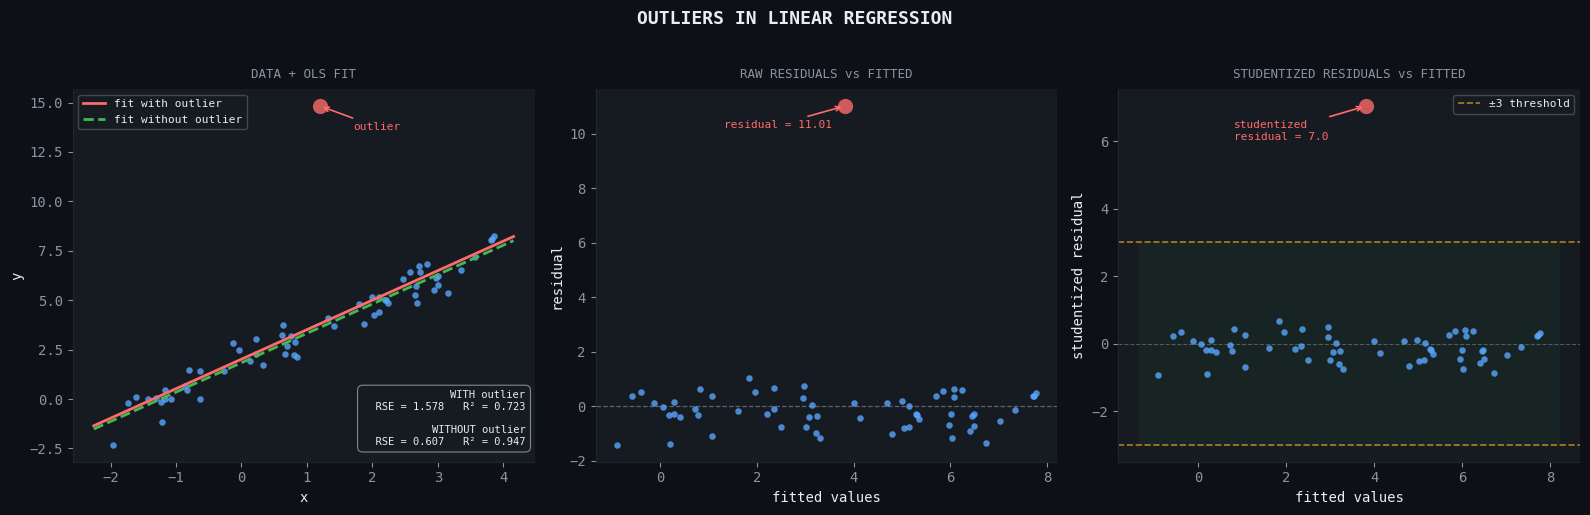

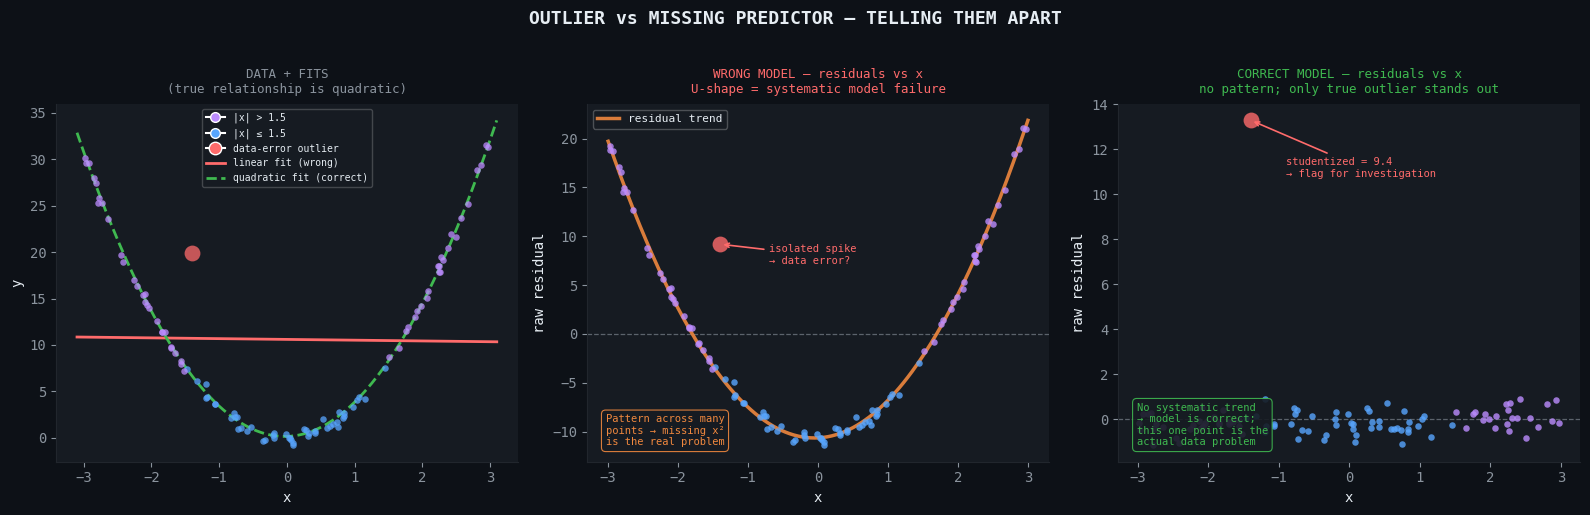

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetics ────────────────────────────────────────────────────────────────
DARK   = "#0d1117"
PANEL  = "#161b22"
GRID   = "#21262d"
TEXT   = "#e6edf3"
MUTED  = "#8b949e"
RED    = "#ff6b6b"
GREEN  = "#3fb950"
BLUE   = "#58a6ff"
YELLOW = "#d29922"
ORANGE = "#f0883e"
PURPLE = "#bc8cff"

plt.rcParams.update({
    "figure.facecolor":  DARK,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "grid.color":        GRID,
    "grid.linewidth":    0.7,
    "text.color":        TEXT,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(42)
n   = 60

# ── Synthetic data ─────────────────────────────────────────────────────────────
x = rng.uniform(-2, 4, n)
true_slope, true_intercept = 1.5, 2.0
y = true_intercept + true_slope * x + rng.normal(0, 0.8, n)

# Inject one clear outlier (high y, typical x)
outlier_idx = 20
x[outlier_idx] = 1.2          # unremarkable x
y[outlier_idx] = y[outlier_idx] + 8.5   # extreme y

# ── Fit models ────────────────────────────────────────────────────────────────
def fit(x, y):
    X = add_constant(x)
    m = OLS(y, X).fit()
    return m

mask = np.ones(n, dtype=bool)
mask[outlier_idx] = False

model_full    = fit(x, y)
model_removed = fit(x[mask], y[mask])

resid_full = model_full.resid
# studentized residuals (internally studentized via influence)
influence   = model_full.get_influence()
stud_resid  = influence.resid_studentized_internal
leverage    = influence.hat_matrix_diag

rse_full    = np.sqrt(model_full.mse_resid)
rse_removed = np.sqrt(model_removed.mse_resid)
r2_full     = model_full.rsquared
r2_removed  = model_removed.rsquared

x_line = np.linspace(x.min() - 0.3, x.max() + 0.3, 200)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – The Classic Three-Panel View
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("OUTLIERS IN LINEAR REGRESSION", fontsize=13,
              fontweight="bold", color=TEXT, y=1.02)

colors_pts = np.where(np.arange(n) == outlier_idx, RED, BLUE)
sizes_pts  = np.where(np.arange(n) == outlier_idx, 120, 22)

# ── Panel 1: scatter + two fits ───────────────────────────────────────────────
ax = axes[0]
for i in range(n):
    ax.scatter(x[i], y[i], color=colors_pts[i], s=sizes_pts[i],
               alpha=0.8, zorder=3, linewidths=0)

ax.plot(x_line, model_full.params[0]    + model_full.params[1]    * x_line,
        color=RED,   lw=2,   label="fit with outlier",    zorder=5)
ax.plot(x_line, model_removed.params[0] + model_removed.params[1] * x_line,
        color=GREEN, lw=2, ls="--", label="fit without outlier", zorder=4)

ax.annotate("outlier", xy=(x[outlier_idx], y[outlier_idx]),
            xytext=(x[outlier_idx] + 0.5, y[outlier_idx] - 1.2),
            color=RED, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))

ax.set_title("DATA + OLS FIT", fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8, framealpha=0.25, loc="upper left")

stats_text = (f"WITH outlier\n"
              f"  RSE = {rse_full:.3f}   R² = {r2_full:.3f}\n\n"
              f"WITHOUT outlier\n"
              f"  RSE = {rse_removed:.3f}   R² = {r2_removed:.3f}")
ax.text(0.98, 0.04, stats_text, transform=ax.transAxes,
        fontsize=7.5, va="bottom", ha="right", color=TEXT,
        bbox=dict(facecolor=PANEL, edgecolor=MUTED, lw=0.8,
                  boxstyle="round,pad=0.5", alpha=0.9))

# ── Panel 2: residuals vs fitted ──────────────────────────────────────────────
ax = axes[1]
fitted = model_full.fittedvalues
for i in range(n):
    ax.scatter(fitted[i], resid_full[i], color=colors_pts[i],
               s=sizes_pts[i], alpha=0.8, zorder=3, linewidths=0)
ax.axhline(0, color=MUTED, lw=0.9, ls="--", alpha=0.6)
ax.annotate(f"residual = {resid_full[outlier_idx]:.2f}",
            xy=(fitted[outlier_idx], resid_full[outlier_idx]),
            xytext=(fitted[outlier_idx] - 2.5, resid_full[outlier_idx] - 0.8),
            color=RED, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax.set_title("RAW RESIDUALS vs FITTED", fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("fitted values"); ax.set_ylabel("residual")

# ── Panel 3: studentized residuals ───────────────────────────────────────────
ax = axes[2]
for i in range(n):
    ax.scatter(fitted[i], stud_resid[i], color=colors_pts[i],
               s=sizes_pts[i], alpha=0.8, zorder=3, linewidths=0)
ax.axhline( 3, color=YELLOW, lw=1.2, ls="--", alpha=0.8, label="±3 threshold")
ax.axhline(-3, color=YELLOW, lw=1.2, ls="--", alpha=0.8)
ax.axhline( 0, color=MUTED,  lw=0.8, ls="--", alpha=0.5)
ax.fill_between(ax.get_xlim(), -3, 3, color=GREEN, alpha=0.05)
ax.annotate(f"studentized\nresidual = {stud_resid[outlier_idx]:.1f}",
            xy=(fitted[outlier_idx], stud_resid[outlier_idx]),
            xytext=(fitted[outlier_idx] - 3.0, stud_resid[outlier_idx] - 1.0),
            color=RED, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax.set_title("STUDENTIZED RESIDUALS vs FITTED", fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("fitted values"); ax.set_ylabel("studentized residual")
ax.legend(fontsize=8, framealpha=0.25)

fig1.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Outlier vs Missing Predictor
# Key insight: a missing predictor creates a *systematic pattern* in residuals
# (U-shape), whereas a true data-error outlier appears as an isolated spike.
# Studentized residuals self-normalize and can't flag the pattern; raw residuals
# plotted vs x reveal it clearly.
# ══════════════════════════════════════════════════════════════════════════════
rng2  = np.random.default_rng(7)
n2    = 100

x1 = rng2.uniform(-3, 3, n2)
y2 = 0.3 * x1 + 3.5 * x1**2 + rng2.normal(0, 0.5, n2)

error_idx = 40
y2[error_idx] += 14.0

model_wrong  = fit(x1, y2)
resid_wrong  = model_wrong.resid
stud_wrong   = model_wrong.get_influence().resid_studentized_internal

X_correct     = add_constant(np.column_stack([x1, x1**2]))
model_correct = OLS(y2, X_correct).fit()
resid_correct = model_correct.resid
stud_correct  = model_correct.get_influence().resid_studentized_internal

extreme     = np.abs(x1) > 1.5
group_color = np.where(extreme, PURPLE, BLUE).tolist()
group_color[error_idx] = RED
sizes2 = np.full(n2, 22); sizes2[error_idx] = 130

x_line2 = np.linspace(-3.1, 3.1, 300)
x_sort  = np.linspace(-3, 3, 200)

from matplotlib.lines import Line2D
legend_pts = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PURPLE,
           markersize=7, label="|x| > 1.5"),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=BLUE,
           markersize=7, label="|x| ≤ 1.5"),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=RED,
           markersize=9, label="data-error outlier"),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("OUTLIER vs MISSING PREDICTOR — TELLING THEM APART",
              fontsize=13, fontweight="bold", color=TEXT, y=1.02)

# ── Panel 1: scatter + both fits ─────────────────────────────────────────────
ax = axes2[0]
for i in range(n2):
    ax.scatter(x1[i], y2[i], color=group_color[i], s=sizes2[i],
               alpha=0.75, zorder=3, linewidths=0)
ax.plot(x_line2,
        model_wrong.params[0] + model_wrong.params[1] * x_line2,
        color=RED, lw=2, label="linear fit (wrong)")
ax.plot(x_line2,
        model_correct.params[0] + model_correct.params[1]*x_line2
        + model_correct.params[2]*x_line2**2,
        color=GREEN, lw=2, ls="--", label="quadratic fit (correct)")
ax.set_title("DATA + FITS\n(true relationship is quadratic)",
             fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(handles=legend_pts + [
    Line2D([0],[0], color=RED,   lw=2,       label="linear fit (wrong)"),
    Line2D([0],[0], color=GREEN, lw=2, ls="--", label="quadratic fit (correct)"),
], fontsize=7, framealpha=0.25)

# ── Panel 2: raw residuals vs x — wrong model shows U-shape + spike ──────────
ax = axes2[1]
for i in range(n2):
    ax.scatter(x1[i], resid_wrong[i], color=group_color[i], s=sizes2[i],
               alpha=0.8, zorder=3, linewidths=0)
ax.axhline(0, color=MUTED, lw=0.9, ls="--", alpha=0.6)

# Fit a smooth curve to residuals (excluding outlier) to show the U-shape
mask_no_out = np.arange(n2) != error_idx
c = np.polyfit(x1[mask_no_out], resid_wrong[mask_no_out], 2)
ax.plot(x_sort, np.polyval(c, x_sort),
        color=ORANGE, lw=2.5, alpha=0.9, label="residual trend")

ax.annotate("isolated spike\n→ data error?",
            xy=(x1[error_idx], resid_wrong[error_idx]),
            xytext=(x1[error_idx] + 0.7, resid_wrong[error_idx] - 2),
            color=RED, fontsize=7.5,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax.set_title("WRONG MODEL — residuals vs x\nU-shape = systematic model failure",
             fontsize=9, color=RED, pad=8)
ax.set_xlabel("x"); ax.set_ylabel("raw residual")
ax.legend(fontsize=8, framealpha=0.3)
ax.text(0.04, 0.04,
        "Pattern across many\npoints → missing x²\nis the real problem",
        transform=ax.transAxes, fontsize=7.5, va="bottom", color=ORANGE,
        bbox=dict(facecolor=PANEL, edgecolor=ORANGE, lw=0.8,
                  boxstyle="round,pad=0.4", alpha=0.9))

# ── Panel 3: raw residuals vs x — correct model is flat, spike remains ────────
ax = axes2[2]
for i in range(n2):
    ax.scatter(x1[i], resid_correct[i], color=group_color[i], s=sizes2[i],
               alpha=0.8, zorder=3, linewidths=0)
ax.axhline(0, color=MUTED, lw=0.9, ls="--", alpha=0.6)
ax.annotate(f"studentized = {stud_correct[error_idx]:.1f}\n→ flag for investigation",
            xy=(x1[error_idx], resid_correct[error_idx]),
            xytext=(x1[error_idx] + 0.5, resid_correct[error_idx] - 2.5),
            color=RED, fontsize=7.5,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax.set_title("CORRECT MODEL — residuals vs x\nno pattern; only true outlier stands out",
             fontsize=9, color=GREEN, pad=8)
ax.set_xlabel("x"); ax.set_ylabel("raw residual")
ax.text(0.04, 0.04,
        "No systematic trend\n→ model is correct;\nthis one point is the\nactual data problem",
        transform=ax.transAxes, fontsize=7.5, va="bottom", color=GREEN,
        bbox=dict(facecolor=PANEL, edgecolor=GREEN, lw=0.8,
                  boxstyle="round,pad=0.4", alpha=0.9))

fig2.tight_layout()
plt.show()

Top Figure: Illustration of an outlier in a linear regression. Scatterplot shows the diffence in RSE and R^2 when including and not including the outlier. Studentized residual identifies the point definitively as an outlier.
Bottom Figure: Compares the studentized residuals of a model which has a missing predictor vs a model with all predictors included. The model with the missing predictor has a fundamental issue, as its residuals follow a U shape pattern, rather than being randomly distributed. 

High Leverage Points

A high leverage observation is one with an extreme X value. Because the least squares line is pulled toward every point, observations at extreme x-values are like a long lever arm. They can haev a heavily outsized influence on the regression line. They are more impactful than ordinary outliers, which tend to leave the fit mostly intact. This is harder to detect in multiple regression, where a point can have normal values on every individual predictor (Xi) and still be extreme when all predictors are combined. Leverage is quantified by the leverage statistic hi​, which ranges from 1/n to 1. Any observation with an hi that​ greatly exceeds (p+1)/n should be looked into. The issue is especially bad when a point has high leverage and is an outlier, meaning the regression line will be heavily altered. 


Question: why does removing a high-leverage point change the slope so much, whereas removing an outlier usually doesn't? 

Answer: It is related to how OLS is calculated. Every point exerts a pull on the fitted line proportional to both its residual and its leverage. This is described formally by the "influence" of an observation, often measured by Cook's Distance.

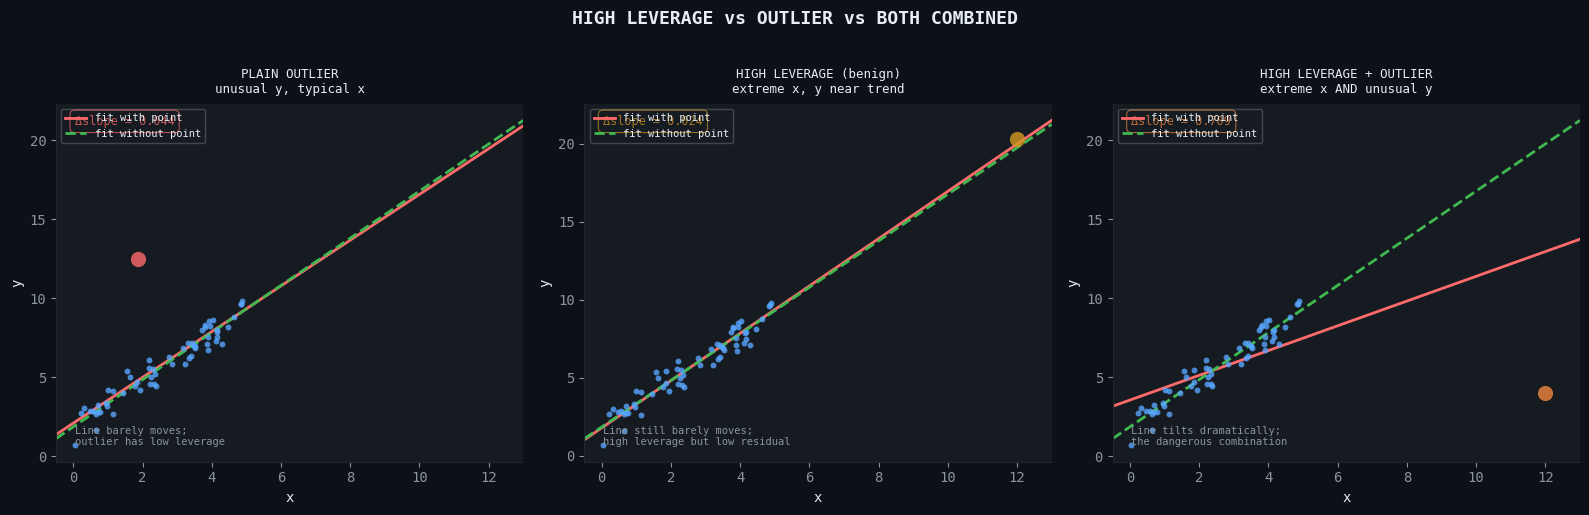

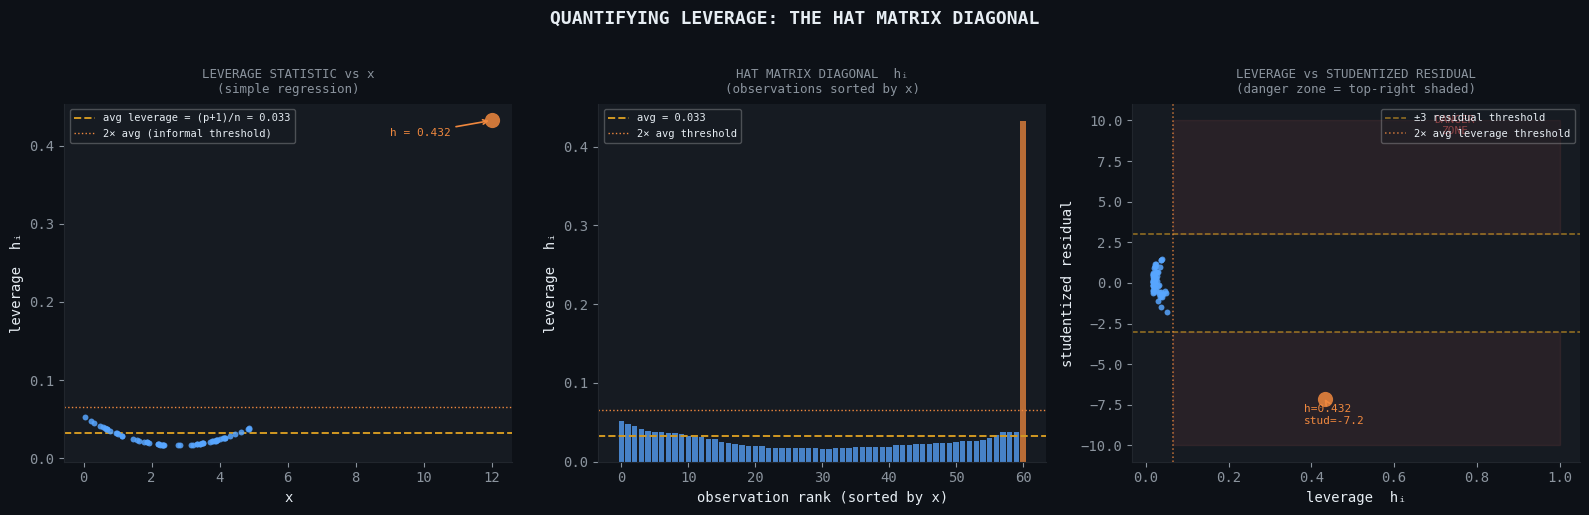

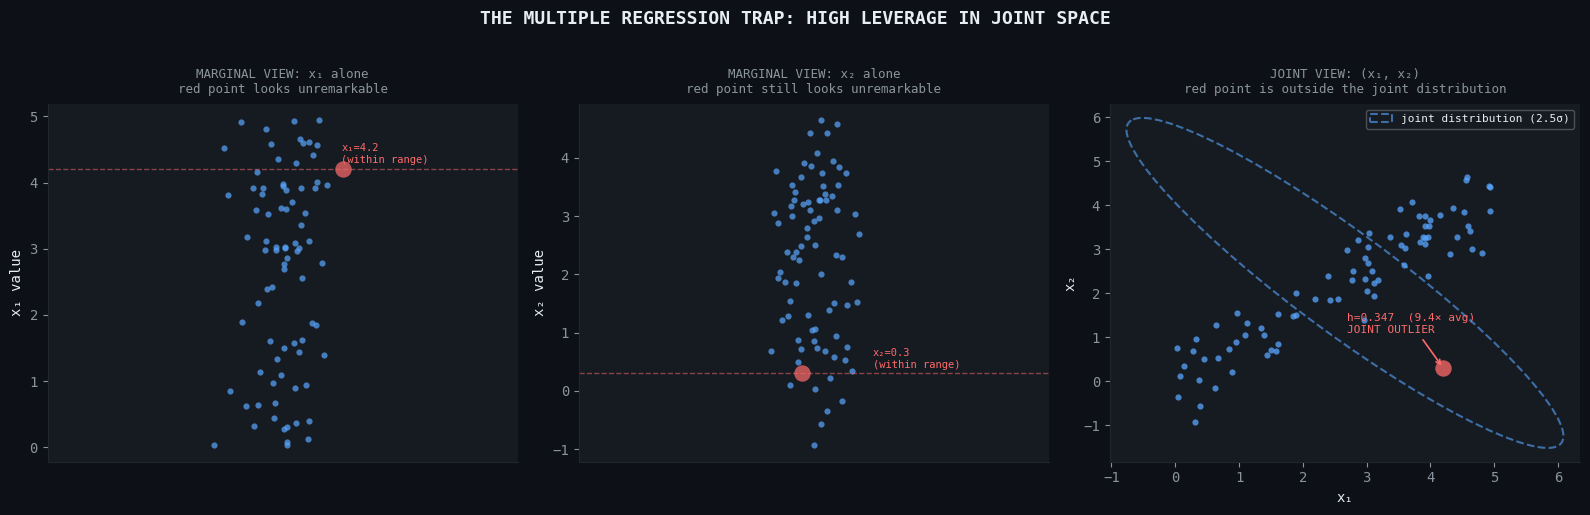

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetics ────────────────────────────────────────────────────────────────
DARK   = "#0d1117"
PANEL  = "#161b22"
GRID   = "#21262d"
TEXT   = "#e6edf3"
MUTED  = "#8b949e"
RED    = "#ff6b6b"
GREEN  = "#3fb950"
BLUE   = "#58a6ff"
YELLOW = "#d29922"
ORANGE = "#f0883e"
PURPLE = "#bc8cff"

plt.rcParams.update({
    "figure.facecolor":  DARK,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "grid.color":        GRID,
    "grid.linewidth":    0.7,
    "text.color":        TEXT,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(42)
n   = 60

# ── Base data: clean linear relationship ──────────────────────────────────────
x_base = rng.uniform(0, 5, n)
y_base = 1.5 * x_base + 2.0 + rng.normal(0, 0.8, n)

# High leverage point: extreme x, y consistent with the trend (benign)
x_highlev_good = np.append(x_base, 12.0)
y_highlev_good = np.append(y_base, 1.5 * 12.0 + 2.0 + 0.3)   # near the line

# High leverage + outlier: extreme x AND unusual y (dangerous)
x_highlev_bad  = np.append(x_base, 12.0)
y_highlev_bad  = np.append(y_base, 4.0)   # far below the trend

# Plain outlier (for comparison): typical x, extreme y
x_outlier      = x_base.copy()
y_outlier      = y_base.copy()
y_outlier[10] += 7.0

def fit(x, y):
    return OLS(y, add_constant(x)).fit()

def leverage_simple(x):
    x_mean = x.mean()
    return 1/len(x) + (x - x_mean)**2 / np.sum((x - x_mean)**2)

m_base        = fit(x_base, y_base)
m_good        = fit(x_highlev_good, y_highlev_good)
m_good_rm     = fit(x_base, y_highlev_good[:n])          # remove the leverage pt
m_bad         = fit(x_highlev_bad,  y_highlev_bad)
m_bad_rm      = fit(x_base, y_highlev_bad[:n])
m_out         = fit(x_outlier, y_outlier)
m_out_rm      = fit(x_base, y_base)

x_line = np.linspace(-0.5, 13, 300)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Three Scenarios Side by Side
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("HIGH LEVERAGE vs OUTLIER vs BOTH COMBINED",
              fontsize=13, fontweight="bold", color=TEXT, y=1.02)

scenarios = [
    # (x, y, model_full, model_removed, special_idx, special_color, title, note)
    (x_outlier, y_outlier, m_out, m_out_rm, 10, RED,
     "PLAIN OUTLIER\nunusual y, typical x",
     "Line barely moves;\noutlier has low leverage"),
    (x_highlev_good, y_highlev_good, m_good, m_good_rm, n, YELLOW,
     "HIGH LEVERAGE (benign)\nextreme x, y near trend",
     "Line still barely moves;\nhigh leverage but low residual"),
    (x_highlev_bad, y_highlev_bad, m_bad, m_bad_rm, n, ORANGE,
     "HIGH LEVERAGE + OUTLIER\nextreme x AND unusual y",
     "Line tilts dramatically;\nthe dangerous combination"),
]

for ax, (xd, yd, mf, mr, sp_idx, sp_col, title, note) in zip(axes, scenarios):
    colors = np.full(len(xd), BLUE, dtype=object)
    sizes  = np.full(len(xd), 18)
    colors[sp_idx] = sp_col
    sizes[sp_idx]  = 120

    for i in range(len(xd)):
        ax.scatter(xd[i], yd[i], color=colors[i], s=sizes[i],
                   alpha=0.8, zorder=3, linewidths=0)

    ax.plot(x_line, mf.params[0] + mf.params[1]*x_line,
            color=RED, lw=2, label="fit with point")
    ax.plot(x_line, mr.params[0] + mr.params[1]*x_line,
            color=GREEN, lw=2, ls="--", label="fit without point")

    slope_diff = abs(mf.params[1] - mr.params[1])
    ax.set_title(title, fontsize=9, color=TEXT, pad=8)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-0.5, 13)
    ax.legend(fontsize=7.5, framealpha=0.25)
    ax.text(0.04, 0.97, f"Δslope = {slope_diff:.3f}",
            transform=ax.transAxes, fontsize=8.5, va="top", color=sp_col,
            bbox=dict(facecolor=PANEL, edgecolor=sp_col, lw=0.8,
                      boxstyle="round,pad=0.4", alpha=0.9))
    ax.text(0.04, 0.04, note, transform=ax.transAxes,
            fontsize=7.5, va="bottom", color=MUTED)

fig1.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Leverage Statistic: Formula Visualized + Hat Matrix (multiple reg)
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("QUANTIFYING LEVERAGE: THE HAT MATRIX DIAGONAL",
              fontsize=13, fontweight="bold", color=TEXT, y=1.02)

# ── Panel 1: leverage statistic vs x for the dangerous scenario ──────────────
ax = axes2[0]
h_vals = leverage_simple(x_highlev_bad)
avg_h  = 2 / len(x_highlev_bad)   # (p+1)/n = 2/n for simple regression

pt_colors = np.full(len(x_highlev_bad), BLUE, dtype=object)
pt_colors[n] = ORANGE
pt_sizes  = np.full(len(x_highlev_bad), 18)
pt_sizes[n] = 120

for i in range(len(x_highlev_bad)):
    ax.scatter(x_highlev_bad[i], h_vals[i], color=pt_colors[i],
               s=pt_sizes[i], alpha=0.85, zorder=3, linewidths=0)

ax.axhline(avg_h, color=YELLOW, lw=1.4, ls="--",
           label=f"avg leverage = (p+1)/n = {avg_h:.3f}")
ax.axhline(2*avg_h, color=ORANGE, lw=1.0, ls=":",
           label=f"2× avg (informal threshold)")

ax.annotate(f"h = {h_vals[n]:.3f}", xy=(x_highlev_bad[n], h_vals[n]),
            xytext=(x_highlev_bad[n] - 3, h_vals[n] - 0.02),
            color=ORANGE, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.2))
ax.set_title("LEVERAGE STATISTIC vs x\n(simple regression)", fontsize=9,
             color=MUTED, pad=8)
ax.set_xlabel("x"); ax.set_ylabel("leverage  hᵢ")
ax.legend(fontsize=7.5, framealpha=0.3)

# ── Panel 2: the hat matrix diagonal visualized as a heatmap ─────────────────
ax = axes2[1]
X_mat = add_constant(x_highlev_bad)
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
h_diag = np.diag(H)

# Sort by x for a clean visual
order  = np.argsort(x_highlev_bad)
colors_sorted = [pt_colors[i] for i in order]
h_sorted      = h_diag[order]
x_sorted      = x_highlev_bad[order]

bars = ax.bar(np.arange(len(x_sorted)), h_sorted,
              color=colors_sorted, alpha=0.75, width=0.8)
ax.axhline(avg_h,   color=YELLOW, lw=1.4, ls="--", label=f"avg = {avg_h:.3f}")
ax.axhline(2*avg_h, color=ORANGE, lw=1.0, ls=":", label="2× avg threshold")
ax.set_title("HAT MATRIX DIAGONAL  hᵢ\n(observations sorted by x)",
             fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("observation rank (sorted by x)")
ax.set_ylabel("leverage  hᵢ")
ax.legend(fontsize=7.5, framealpha=0.3)

# ── Panel 3: leverage vs studentized residual (the classic diagnostic) ─────────
ax = axes2[2]
stud = m_bad.get_influence().resid_studentized_internal
h_d  = m_bad.get_influence().hat_matrix_diag

pt_c2 = np.full(len(x_highlev_bad), BLUE, dtype=object)
pt_c2[n] = ORANGE
pt_s2 = np.full(len(x_highlev_bad), 18)
pt_s2[n] = 120

for i in range(len(x_highlev_bad)):
    ax.scatter(h_d[i], stud[i], color=pt_c2[i], s=pt_s2[i],
               alpha=0.85, zorder=3, linewidths=0)

ax.axhline( 3, color=YELLOW, lw=1.1, ls="--", alpha=0.7, label="±3 residual threshold")
ax.axhline(-3, color=YELLOW, lw=1.1, ls="--", alpha=0.7)
ax.axvline(2*avg_h, color=ORANGE, lw=1.1, ls=":", alpha=0.8,
           label=f"2× avg leverage threshold")

# Shade the four quadrants
xlim_r = ax.get_xlim(); ylim_r = ax.get_ylim()
ax.fill_between([2*avg_h, 1.0], [3, 3], [10, 10],
                color=RED, alpha=0.08, zorder=0)   # danger zone: high lev + high resid
ax.fill_between([2*avg_h, 1.0], [-10, -10], [-3, -3],
                color=RED, alpha=0.08, zorder=0)

ax.annotate(f"h={h_d[n]:.3f}\nstud={stud[n]:.1f}",
            xy=(h_d[n], stud[n]),
            xytext=(h_d[n] - 0.05, stud[n] - 1.5),
            color=ORANGE, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.2))
ax.set_title("LEVERAGE vs STUDENTIZED RESIDUAL\n(danger zone = top-right shaded)",
             fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("leverage  hᵢ"); ax.set_ylabel("studentized residual")
ax.legend(fontsize=7.5, framealpha=0.3)
ax.text(0.72, 0.97, "DANGER\nZONE", transform=ax.transAxes,
        fontsize=8, color=RED, va="top", ha="center", alpha=0.7)

fig2.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – The Multiple Regression Trap
# A point can be inside the marginal range of every predictor yet be extreme
# in the joint predictor space.
# ══════════════════════════════════════════════════════════════════════════════
rng3 = np.random.default_rng(9)
n3   = 80

# Two correlated predictors
x1 = rng3.uniform(0, 5, n3)
x2 = 0.8 * x1 + rng3.normal(0, 0.5, n3)   # x2 strongly correlated with x1
y3 = 1.0 + 0.5*x1 + 0.5*x2 + rng3.normal(0, 0.4, n3)

# High-leverage point: x1 and x2 each within range, but wrong combination
# (high x1, low x2 — off the joint distribution)
x1_lev = np.append(x1, 4.2)
x2_lev = np.append(x2, 0.3)    # x1 high but x2 low — unusual joint
y3_lev = np.append(y3, 1.0 + 0.5*4.2 + 0.5*0.3 + rng3.normal(0, 0.4))

# Compute leverage for multiple regression
X3 = add_constant(np.column_stack([x1_lev, x2_lev]))
m3 = OLS(y3_lev, X3).fit()
h3 = m3.get_influence().hat_matrix_diag
avg_h3 = 3 / len(x1_lev)   # (p+1)/n = 3/n

sp = n3   # index of special point
pt_col3 = np.full(len(x1_lev), BLUE, dtype=object)
pt_col3[sp] = RED
pt_sz3 = np.full(len(x1_lev), 20)
pt_sz3[sp] = 140

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle("THE MULTIPLE REGRESSION TRAP: HIGH LEVERAGE IN JOINT SPACE",
              fontsize=13, fontweight="bold", color=TEXT, y=1.02)

# ── Panel 1: x1 alone — red point looks fine ─────────────────────────────────
ax = axes3[0]
for i in range(len(x1_lev)):
    ax.scatter(np.zeros(1) + rng3.normal(0, 0.04), [x1_lev[i]],
               color=pt_col3[i], s=pt_sz3[i], alpha=0.7, linewidths=0)
ax.set_xlim(-0.4, 0.4)
ax.set_xticks([])
ax.set_title("MARGINAL VIEW: x₁ alone\nred point looks unremarkable",
             fontsize=9, color=MUTED, pad=8)
ax.set_ylabel("x₁ value")
ax.axhline(x1_lev[sp], color=RED, lw=1, ls="--", alpha=0.5)
ax.text(0.1, x1_lev[sp] + 0.1, f"x₁={x1_lev[sp]:.1f}\n(within range)",
        color=RED, fontsize=7.5)

# ── Panel 2: x2 alone — red point also looks fine ────────────────────────────
ax = axes3[1]
for i in range(len(x2_lev)):
    ax.scatter(np.zeros(1) + rng3.normal(0, 0.04), [x2_lev[i]],
               color=pt_col3[i], s=pt_sz3[i], alpha=0.7, linewidths=0)
ax.set_xlim(-0.4, 0.4)
ax.set_xticks([])
ax.set_title("MARGINAL VIEW: x₂ alone\nred point still looks unremarkable",
             fontsize=9, color=MUTED, pad=8)
ax.set_ylabel("x₂ value")
ax.axhline(x2_lev[sp], color=RED, lw=1, ls="--", alpha=0.5)
ax.text(0.1, x2_lev[sp] + 0.1, f"x₂={x2_lev[sp]:.1f}\n(within range)",
        color=RED, fontsize=7.5)

# ── Panel 3: joint (x1, x2) — red point is clearly off the cloud ─────────────
ax = axes3[2]
for i in range(len(x1_lev)):
    ax.scatter(x1_lev[i], x2_lev[i], color=pt_col3[i], s=pt_sz3[i],
               alpha=0.75, zorder=3, linewidths=0)

# Draw ellipse representing the joint distribution of the normal points
cov  = np.cov(x1[:n3], x2[:n3])
vals, vecs = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(*vecs[:, -1][::-1]))
w, h_ = 2 * 2.5 * np.sqrt(vals)   # 2.5σ ellipse
ell = Ellipse(xy=(x1[:n3].mean(), x2[:n3].mean()), width=w, height=h_,
              angle=angle, edgecolor=BLUE, facecolor="none",
              lw=1.5, ls="--", alpha=0.6, label="joint distribution (2.5σ)")
ax.add_patch(ell)

ax.annotate(f"h={h3[sp]:.3f}  ({h3[sp]/avg_h3:.1f}× avg)\nJOINT OUTLIER",
            xy=(x1_lev[sp], x2_lev[sp]),
            xytext=(x1_lev[sp] - 1.5, x2_lev[sp] + 0.8),
            color=RED, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax.set_title("JOINT VIEW: (x₁, x₂)\nred point is outside the joint distribution",
             fontsize=9, color=MUTED, pad=8)
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.legend(fontsize=8, framealpha=0.3)

fig3.tight_layout()
plt.show()

Top Figure: Compares a regular outlier to a high leverage point and how that affects the regression line. Then, shows a point which is both an outlier and high leverage point. This has a very large effect on the regression line.
Middle Figure: Illustrates hi, the leverage statistic. Shows how hi increases with distance from x.
Bottom: Illustrates a high leverage point in a multiple linear regression context. While the point is normal for both X predictors individually, it is extreme in the combined predictor plot.  

AI Reflection

I used Claude to produce the code for this assignment. I fed Claude the prompt from the homework assigment: 1. generates synthetic data that clearly illustrates the issue 2. produces plots making the issue visually clear 3. where applicable, produces additional plots showing how the issue can be addressed. It produced functional code with no errors on the first try. However, for the second issue, I noticed that one of the plots it produced did not match the descrpition Claude provided. I reran it to produce a plot that accurately reflected what Claude was trying to illustrate. 